# Genre Prediction — Round 2: Squeezing More from Naive Bayes

**Constraints:** Naive Bayes only, no embeddings, no TF-IDF/vectorizers. Pure statistical feature engineering.

**Round 1 best:** F1 ≈ 0.265 (BernoulliNB, kitchen sink with treated categoricals)

**New ideas in this notebook:**

| # | Experiment | Key idea |
|---|-----------|----------|
| 9 | One-hot top-N keywords | Binary columns for the 50 most common keywords |
| 10 | One-hot top-N across all list cols | Binary cols for top values in cast, directors, writers, companies, countries, languages, keywords |
| 11 | Frequency encoding | Replace categorical values by their dataset frequency |
| 12 | Target encoding (CV-safe) | Encode categoricals by per-genre probability (with fold-based leakage prevention) |
| 13 | Genre merging | Merge similar/overlapping genres (sci-fi+science fiction, reduce to ~12 classes) |
| 14 | One-vs-Rest BernoulliNB | Train one binary NB per genre instead of one multiclass model |
| 15 | Feature selection | Mutual-information-based feature selection to remove noise |
| 16 | Class balancing | Oversample minority / undersample majority classes |
| 17 | Best combo | Combine the winning ideas from above |

---


In [11]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, LabelEncoder, MultiLabelBinarizer, LabelBinarizer
)
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

DATA_DIR = Path('./data')
RESULTS_DIR = Path('./results_round2')
RESULTS_DIR.mkdir(exist_ok=True)

FILE_CONFIG = {
    'TMDB IMDB Movies Dataset': {
        'filename': 'TMDB IMDB Movies Dataset.csv',
        'column_mappings': {'original_title': 'title'}
    },
    'merged_dataset': {
        'filename': 'merged_dataset.csv',
        'column_mappings': {
            'name': 'title', 'rating': 'vote_average',
            'num_raters': 'vote_count', 'run_length': 'runtime',
            'year': 'release_date'
        }
    }
}

USELESS_COLS = ['id', 'backdrop_path', 'poster_path', 'homepage', 'tconst', 'original_title']
NUMERIC_COLS = ['vote_average', 'vote_count', 'revenue', 'runtime', 'budget',
                'popularity', 'averagerating', 'numvotes']
BOOLEAN_COLS = ['adult']
LIST_LIKE_COLS = ['genres', 'production_companies', 'production_countries',
                  'spoken_languages', 'keywords', 'directors', 'writers', 'cast']
EMPTY_ALIASES = ['unknown', 'unset', '', 'nan', 'none', 'n/a', 'na']
RANDOM_STATE = 42

print("Configuration loaded.")


Configuration loaded.


## 1. Load & Clean Data

In [12]:
dfs = []
for name, config in FILE_CONFIG.items():
    fp = DATA_DIR / config['filename']
    print(f"Loading {fp}...")
    tmp = pd.read_csv(fp, low_memory=False)
    tmp.rename(columns=config['column_mappings'], inplace=True)
    tmp = tmp.loc[:, ~tmp.columns.duplicated()]
    tmp['_source'] = name
    dfs.append(tmp)

df_raw = pd.concat(dfs, ignore_index=True)

# Standardise column names
df_raw.columns = (
    df_raw.columns.str.strip().str.lower()
    .str.replace(r'[\s\-\.]+', '_', regex=True)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)

# Drop useless
useless = [c.strip().lower().replace(' ','_').replace('-','_').replace('.','_') for c in USELESS_COLS]
df_raw.drop(columns=[c for c in useless if c in df_raw.columns], inplace=True, errors='ignore')

# Drop >=80% empty columns
def calc_empty_ratio(s):
    is_empty = s.isna()
    if s.dtype == object:
        is_empty = is_empty | s.astype(str).str.strip().str.lower().isin(EMPTY_ALIASES)
    return is_empty.mean()
empty_ratios = df_raw.apply(calc_empty_ratio)
df_raw.drop(columns=empty_ratios[empty_ratios >= 0.8].index, inplace=True)

# Standardise strings
for col in df_raw.select_dtypes(include='object').columns:
    df_raw[col] = df_raw[col].astype(str).str.strip().str.lower()
    df_raw[col] = df_raw[col].replace(EMPTY_ALIASES, np.nan)
    df_raw[col] = df_raw[col].str.strip(';,| ')

# Drop empty genres
df_raw = df_raw[df_raw['genres'].notna() & (df_raw['genres'].str.strip() != '')]

# Standardise numerics
for col in NUMERIC_COLS:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col].squeeze(), errors='coerce')

# Booleans
for col in BOOLEAN_COLS:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].astype(str).str.strip().str.lower().map(
            {'true':1,'false':0,'1':1,'0':0,'1.0':1,'0.0':0,'yes':1,'no':0}
        ).fillna(0).astype(int)

# Parse list-like columns
def parse_list(val):
    if pd.isna(val): return []
    val = str(val).strip()
    if not val: return []
    items = [x.strip() for x in val.replace(';', ',').split(',')]
    return [x for x in items if x and x not in EMPTY_ALIASES]

for col in LIST_LIKE_COLS:
    if col in df_raw.columns:
        df_raw[f'{col}_parsed'] = df_raw[col].apply(parse_list)
        df_raw[f'{col}_count'] = df_raw[f'{col}_parsed'].apply(len)

# Parse release_date
if 'release_date' in df_raw.columns:
    date_raw = df_raw['release_date'].astype(str).str.replace(r'\(.*?\)', '', regex=True).str.strip()
    parsed = pd.to_datetime(date_raw, format='%Y-%m-%d', errors='coerce')
    mask = parsed.isna()
    parsed[mask] = pd.to_datetime(date_raw[mask], format='mixed', errors='coerce')
    df_raw['release_year'] = parsed.dt.year
    df_raw['release_month'] = parsed.dt.month
    df_raw.drop(columns=['release_date'], inplace=True)

# Genre
df_raw['genres_parsed'] = df_raw['genres'].apply(parse_list) if 'genres_parsed' not in df_raw.columns else df_raw['genres_parsed']
df_raw['genre_count'] = df_raw['genres_parsed'].apply(len)
df_raw['genre_label'] = df_raw['genres_parsed'].apply(lambda lst: lst[0] if lst else np.nan)
df_raw = df_raw[df_raw['genre_label'].notna()]

print(f"Cleaned: {df_raw.shape[0]} rows, {df_raw.shape[1]} cols")
print(f"Genre classes: {df_raw['genre_label'].nunique()}")


Loading data\TMDB IMDB Movies Dataset.csv...
Loading data\merged_dataset.csv...
Cleaned: 357787 rows, 43 cols
Genre classes: 21


## 2. Shared Utilities

In [13]:
NUMERIC_FEATURES = ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes',
                    'vote_average', 'vote_count', 'budget', 'revenue']

LIST_CAT_COLS = ['cast', 'directors', 'writers', 'production_companies',
                 'production_countries', 'spoken_languages', 'keywords']


def build_numeric(df):
    avail = [c for c in NUMERIC_FEATURES if c in df.columns]
    X = df[avail].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col].squeeze(), errors='coerce')
    return X


def build_count_features(df):
    cols = [c for c in df.columns if c.endswith('_count') and c != 'genre_count']
    return df[cols].copy()


def build_top1_cat(df, top_n=20):
    """Extract first element from each list column, keep only top_n values, rest -> other_cat."""
    result = pd.DataFrame(index=df.index)
    for col in LIST_CAT_COLS:
        parsed = f'{col}_parsed'
        if parsed in df.columns:
            result[f'{col}_top1'] = df[parsed].apply(lambda lst: lst[0] if lst else np.nan)
            counts = result[f'{col}_top1'].value_counts()
            top_vals = set(counts.head(top_n).index)
            result[f'{col}_top1'] = result[f'{col}_top1'].apply(
                lambda x: x if x in top_vals else 'other_cat'
            )
    for col in ['original_language', 'status']:
        if col in df.columns:
            result[col] = df[col]
    return result


def onehot_topn(df, col_parsed, top_n=30, prefix=None):
    """Create binary columns for the top_n most frequent values in a parsed list column."""
    if prefix is None:
        prefix = col_parsed.replace('_parsed', '')
    all_vals = [v for lst in df[col_parsed] for v in lst]
    top_vals = [val for val, _ in Counter(all_vals).most_common(top_n)]
    result = pd.DataFrame(index=df.index)
    for val in top_vals:
        safe = val.replace(' ', '_').replace('-', '_').replace('.', '_')[:25]
        result[f'{prefix}__{safe}'] = df[col_parsed].apply(lambda lst: int(val in lst))
    return result


def frequency_encode(series):
    """Replace each value with its frequency (count / total)."""
    freq_map = series.value_counts(normalize=True).to_dict()
    return series.map(freq_map).fillna(0)


def target_encode_cv(X_col, y, n_splits=5):
    """
    Target-encode a categorical column using cross-validation to prevent leakage.
    Vectorised: uses groupby instead of looping through unique values.
    Score = max P(class | value), i.e. how concentrated the genre distribution is.
    """
    encoded = pd.Series(0.5, index=X_col.index, dtype=float)

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    for train_idx, val_idx in kf.split(X_col, y):
        train_x = X_col.iloc[train_idx]
        train_y = y.iloc[train_idx]

        # Vectorised: for each category value, max(class proportion)
        tmp = pd.DataFrame({'val': train_x.values, 'target': train_y.values})
        # Count (value, target) pairs, then get max proportion per value
        counts = tmp.groupby(['val', 'target']).size().unstack(fill_value=0)
        max_prob = counts.div(counts.sum(axis=1), axis=0).max(axis=1)

        encoded.iloc[val_idx] = X_col.iloc[val_idx].map(max_prob).fillna(0.5)

    return encoded


def label_encode_col(series):
    """Label-encode a categorical series, NaN -> 'missing'."""
    s = series.fillna('missing').astype(str)
    le = LabelEncoder()
    return pd.Series(le.fit_transform(s), index=series.index), le


# --- Genre merging map ---
GENRE_MERGE_MAP = {
    'sci-fi': 'science fiction',
    'biography': 'drama',  # biographies are usually dramas
}

def merge_genres(genre):
    return GENRE_MERGE_MAP.get(genre, genre)


# --- Training function (same 4 NB models) ---
def run_nb_experiment(X, y, name, models=None):
    """Run NB models on X, y. Returns dict with results."""
    print(f"\n{'='*70}")
    print(f"EXPERIMENT: {name}")
    print(f"{'='*70}")

    # Remove classes with <5 samples
    counts = y.value_counts()
    valid = counts[counts >= 5].index
    mask = y.isin(valid)
    X, y = X[mask].copy(), y[mask].copy()

    # Deduplicate columns (keep first occurrence)
    X = X.loc[:, ~X.columns.duplicated()]
    
    print(f"  Rows: {len(X)}, Features: {X.shape[1]}, Classes: {y.nunique()}")

    if len(X) < 50 or y.nunique() < 2:
        print("  *** TOO FEW SAMPLES — skipping ***")
        return None

    # Impute numeric NaN with median
    for col in X.columns:
        X[col] = pd.to_numeric(X[col].squeeze(), errors='coerce')
        if X[col].isna().any():
            X[col] = X[col].fillna(X[col].median())
    X = X.fillna(0)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    # Re-impute with train medians
    train_med = X_train.median()
    X_train = X_train.fillna(train_med).fillna(0)
    X_test = X_test.fillna(train_med).fillna(0)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    if models is None:
        models = {
            'GaussianNB': {
                'pipeline': Pipeline([('scaler', StandardScaler()), ('clf', GaussianNB())]),
                'params': {'clf__var_smoothing': [1e-9, 1e-7, 1e-5, 1e-3]}
            },
            'MultinomialNB': {
                'pipeline': Pipeline([('scaler', MinMaxScaler()), ('clf', MultinomialNB())]),
                'params': {'clf__alpha': [0.01, 0.1, 1.0, 5.0], 'clf__fit_prior': [True, False]}
            },
            'ComplementNB': {
                'pipeline': Pipeline([('scaler', MinMaxScaler()), ('clf', ComplementNB())]),
                'params': {'clf__alpha': [0.01, 0.1, 1.0, 5.0], 'clf__norm': [True, False]}
            },
            'BernoulliNB': {
                'pipeline': Pipeline([('scaler', MinMaxScaler()), ('clf', BernoulliNB())]),
                'params': {'clf__alpha': [0.01, 0.1, 1.0, 5.0], 'clf__binarize': [0.0, 0.25, 0.5, 0.75]}
            },
        }

    results = {}
    for mname, cfg in models.items():
        grid = GridSearchCV(cfg['pipeline'], cfg['params'], cv=cv,
                            scoring='f1_weighted', n_jobs=-1, refit=True)
        grid.fit(X_train, y_train)
        y_pred = grid.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='weighted')
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        results[mname] = {
            'best_cv_f1': grid.best_score_, 'test_f1': f1,
            'test_accuracy': acc, 'test_precision': prec,
            'best_params': grid.best_params_,
            'n_train': len(X_train), 'n_test': len(X_test),
            'n_classes': y.nunique(), 'n_features': X.shape[1],
        }
        print(f"  {mname:15s} | CV F1={grid.best_score_:.4f} | Test F1={f1:.4f} | Acc={acc:.4f}")

    return results


ALL_RESULTS = {}
def store(name, res):
    if res is not None:
        ALL_RESULTS[name] = res

print("Utilities ready.")


Utilities ready.


## 3. Reference Baseline (from Round 1)
Reproducing the best Round 1 setup: numeric + treated categoricals + impute.


In [14]:
X_base_num = build_numeric(df_raw)
X_base_counts = build_count_features(df_raw)
X_base_cat = build_top1_cat(df_raw, top_n=20)

# Label-encode the categorical columns
for col in X_base_cat.columns:
    X_base_cat[col], _ = label_encode_col(X_base_cat[col])

X_base = pd.concat([X_base_num, X_base_counts, X_base_cat], axis=1)
X_base = X_base.loc[:, ~X_base.columns.duplicated()]
y_base = df_raw['genre_label'].copy()

store('R1_baseline_treated_cat', run_nb_experiment(X_base, y_base, 'R1 Baseline (treated cat)'))



EXPERIMENT: R1 Baseline (treated cat)
  Rows: 357784, Features: 26, Classes: 20
  GaussianNB      | CV F1=0.0902 | Test F1=0.0921 | Acc=0.1187
  MultinomialNB   | CV F1=0.2418 | Test F1=0.2381 | Acc=0.2381
  ComplementNB    | CV F1=0.2476 | Test F1=0.2471 | Acc=0.3121
  BernoulliNB     | CV F1=0.2659 | Test F1=0.2651 | Acc=0.3285


## Experiment 9: One-hot binary encoding of top-N keywords
Keywords had the 6th highest MI score. Instead of just a count, let's create binary columns for the most common keywords.


In [15]:
X9_num = build_numeric(df_raw)
X9_counts = build_count_features(df_raw)

# One-hot top 50 keywords
if 'keywords_parsed' in df_raw.columns:
    X9_kw = onehot_topn(df_raw, 'keywords_parsed', top_n=50, prefix='kw')
    print(f"Keyword features: {X9_kw.shape[1]} binary columns")
else:
    X9_kw = pd.DataFrame(index=df_raw.index)
    print("No keywords_parsed column found")

X9 = pd.concat([X9_num, X9_counts, X9_kw], axis=1)
X9 = X9.loc[:, ~X9.columns.duplicated()]
y9 = df_raw['genre_label'].copy()

store('9_onehot_keywords_50', run_nb_experiment(X9, y9, 'One-hot top-50 keywords'))


Keyword features: 50 binary columns

EXPERIMENT: One-hot top-50 keywords
  Rows: 357784, Features: 67, Classes: 20
  GaussianNB      | CV F1=0.0839 | Test F1=0.1045 | Acc=0.0831
  MultinomialNB   | CV F1=0.2082 | Test F1=0.1936 | Acc=0.2143
  ComplementNB    | CV F1=0.2634 | Test F1=0.2637 | Acc=0.3133
  BernoulliNB     | CV F1=0.2969 | Test F1=0.2968 | Acc=0.3523


## Experiment 10: One-hot top-N across all list columns
Binary columns for top values in cast, directors, writers, companies, countries, languages, AND keywords.


In [16]:
X10_num = build_numeric(df_raw)
X10_counts = build_count_features(df_raw)

# One-hot for each list column
onehot_parts = []
top_n_per_col = {
    'keywords': 50,
    'cast': 30,
    'directors': 30,
    'writers': 20,
    'production_companies': 20,
    'production_countries': 15,
    'spoken_languages': 15,
}

for col, n in top_n_per_col.items():
    parsed = f'{col}_parsed'
    if parsed in df_raw.columns:
        oh = onehot_topn(df_raw, parsed, top_n=n, prefix=col[:5])
        onehot_parts.append(oh)
        print(f"  {col}: {oh.shape[1]} binary features")

X10_oh = pd.concat(onehot_parts, axis=1)
X10_oh = X10_oh.loc[:, ~X10_oh.columns.duplicated()]
X10 = pd.concat([X10_num, X10_counts, X10_oh], axis=1)
X10 = X10.loc[:, ~X10.columns.duplicated()]
y10 = df_raw['genre_label'].copy()
print(f"Total features: {X10.shape[1]}")

store('10_onehot_all_lists', run_nb_experiment(X10, y10, 'One-hot top-N all list columns'))


  keywords: 50 binary features
  cast: 30 binary features
  directors: 30 binary features
  writers: 20 binary features
  production_companies: 20 binary features
  production_countries: 15 binary features
  spoken_languages: 15 binary features
Total features: 197

EXPERIMENT: One-hot top-N all list columns
  Rows: 357784, Features: 197, Classes: 20
  GaussianNB      | CV F1=0.0893 | Test F1=0.0915 | Acc=0.0780
  MultinomialNB   | CV F1=0.3046 | Test F1=0.3040 | Acc=0.3533
  ComplementNB    | CV F1=0.2942 | Test F1=0.2922 | Acc=0.3386
  BernoulliNB     | CV F1=0.3414 | Test F1=0.3410 | Acc=0.3862


## Experiment 11: Frequency encoding of categoricals
Replace each categorical value with how often it appears in the dataset. This is a single numeric column per feature (no dimensionality explosion).


In [17]:
X11_num = build_numeric(df_raw)
X11_counts = build_count_features(df_raw)

# Frequency-encode top1 values from list columns
X11_freq = pd.DataFrame(index=df_raw.index)
for col in LIST_CAT_COLS:
    parsed = f'{col}_parsed'
    if parsed in df_raw.columns:
        top1 = df_raw[parsed].apply(lambda lst: lst[0] if lst else 'missing')
        X11_freq[f'{col}_freq'] = frequency_encode(top1)

for col in ['original_language', 'status']:
    if col in df_raw.columns:
        X11_freq[f'{col}_freq'] = frequency_encode(df_raw[col].fillna('missing'))

X11 = pd.concat([X11_num, X11_counts, X11_freq], axis=1)
X11 = X11.loc[:, ~X11.columns.duplicated()]
y11 = df_raw['genre_label'].copy()

store('11_frequency_encoding', run_nb_experiment(X11, y11, 'Frequency encoding'))



EXPERIMENT: Frequency encoding
  Rows: 357784, Features: 26, Classes: 20
  GaussianNB      | CV F1=0.0913 | Test F1=0.0925 | Acc=0.1620
  MultinomialNB   | CV F1=0.2152 | Test F1=0.2155 | Acc=0.3517
  ComplementNB    | CV F1=0.2529 | Test F1=0.2523 | Acc=0.3282
  BernoulliNB     | CV F1=0.2777 | Test F1=0.2761 | Acc=0.3504


## Experiment 12: Target encoding
Encode each categorical value by how "predictive" it is — specifically, how concentrated its genre distribution is. Done with cross-validation to avoid leakage.


In [18]:
X12_num = build_numeric(df_raw)
X12_counts = build_count_features(df_raw)
y12 = df_raw['genre_label'].copy()

import time as _time

X12_te = pd.DataFrame(index=df_raw.index)

# Precompute top1 values (avoid repeated .apply on 350K rows)
_top1_cache = {}
for col in LIST_CAT_COLS:
    parsed = f'{col}_parsed'
    if parsed in df_raw.columns:
        _top1_cache[col] = df_raw[parsed].apply(lambda lst: lst[0] if lst else 'missing')

for col in LIST_CAT_COLS:
    if col in _top1_cache:
        _t0 = _time.time()
        X12_te[f'{col}_te'] = target_encode_cv(_top1_cache[col], y12, n_splits=5)
        print(f"  {col}: target-encoded (mean={X12_te[f'{col}_te'].mean():.3f}) [{_time.time()-_t0:.1f}s]")

for col in ['original_language']:
    if col in df_raw.columns:
        _t0 = _time.time()
        X12_te[f'{col}_te'] = target_encode_cv(
            df_raw[col].fillna('missing'), y12, n_splits=5
        )
        print(f"  {col}: target-encoded [{_time.time()-_t0:.1f}s]")

X12 = pd.concat([X12_num, X12_counts, X12_te], axis=1)
X12 = X12.loc[:, ~X12.columns.duplicated()]

store('12_target_encoding', run_nb_experiment(X12, y12, 'Target encoding'))


  cast: target-encoded (mean=0.583) [5.2s]
  directors: target-encoded (mean=0.628) [4.5s]
  writers: target-encoded (mean=0.623) [5.1s]
  production_companies: target-encoded (mean=0.472) [4.0s]
  production_countries: target-encoded (mean=0.280) [2.8s]
  spoken_languages: target-encoded (mean=0.274) [2.4s]
  keywords: target-encoded (mean=0.360) [2.6s]
  original_language: target-encoded [2.2s]

EXPERIMENT: Target encoding
  Rows: 357784, Features: 25, Classes: 20
  GaussianNB      | CV F1=0.0894 | Test F1=0.0893 | Acc=0.1679
  MultinomialNB   | CV F1=0.2654 | Test F1=0.2610 | Acc=0.2576
  ComplementNB    | CV F1=0.2564 | Test F1=0.2538 | Acc=0.3229
  BernoulliNB     | CV F1=0.2656 | Test F1=0.2617 | Acc=0.3300


## Experiment 13: Merge similar/tiny genres
Merge: sci-fi → science fiction, biography → drama. Then group anything with < 1000 samples into 'other'.
This reduces the number of classes and makes each class more learnable.


In [19]:
df13 = df_raw.copy()
df13['genre_label'] = df13['genre_label'].apply(merge_genres)

# Also group very small classes into 'other'
counts = df13['genre_label'].value_counts()
small_genres = counts[counts < 1000].index.tolist()
df13['genre_label'] = df13['genre_label'].apply(lambda g: 'other' if g in small_genres else g)

print(f"Genre distribution after merging:")
print(df13['genre_label'].value_counts())
print(f"Classes: {df13['genre_label'].nunique()}")

# Use the best feature set from Round 1
X13_num = build_numeric(df13)
X13_counts = build_count_features(df13)
X13_cat = build_top1_cat(df13, top_n=20)
for col in X13_cat.columns:
    X13_cat[col], _ = label_encode_col(X13_cat[col])

X13 = pd.concat([X13_num, X13_counts, X13_cat], axis=1)
X13 = X13.loc[:, ~X13.columns.duplicated()]
y13 = df13['genre_label'].copy()

store('13_genre_merging', run_nb_experiment(X13, y13, 'Merged genres (<1000 -> other)'))


Genre distribution after merging:
genre_label
drama              96525
comedy             63699
documentary        55129
action             20927
animation          20713
horror             20153
thriller           11487
romance            11088
crime              11016
music               7654
adventure           6930
family              5928
science fiction     5068
tv movie            4650
western             4190
fantasy             4083
mystery             3459
war                 2556
history             2532
Name: count, dtype: int64
Classes: 19

EXPERIMENT: Merged genres (<1000 -> other)
  Rows: 357787, Features: 26, Classes: 19
  GaussianNB      | CV F1=0.0928 | Test F1=0.0948 | Acc=0.1216
  MultinomialNB   | CV F1=0.2422 | Test F1=0.2389 | Acc=0.2387
  ComplementNB    | CV F1=0.2478 | Test F1=0.2474 | Acc=0.3120
  BernoulliNB     | CV F1=0.2668 | Test F1=0.2648 | Acc=0.3281


## Experiment 14: One-vs-Rest BernoulliNB
Instead of one multiclass model, train a separate binary BernoulliNB for each genre class. Each model learns "is this genre X? yes/no" independently.


In [20]:
from sklearn.multiclass import OneVsRestClassifier

X14_num = build_numeric(df_raw)
X14_counts = build_count_features(df_raw)
X14_cat = build_top1_cat(df_raw, top_n=20)
for col in X14_cat.columns:
    X14_cat[col], _ = label_encode_col(X14_cat[col])
X14 = pd.concat([X14_num, X14_counts, X14_cat], axis=1)
X14 = X14.loc[:, ~X14.columns.duplicated()]
y14 = df_raw['genre_label'].copy()

# Remove tiny classes
counts = y14.value_counts()
valid = counts[counts >= 5].index
mask = y14.isin(valid)
X14, y14 = X14[mask].copy(), y14[mask].copy()

# Impute
for col in X14.columns:
    X14[col] = pd.to_numeric(X14[col].squeeze(), errors='coerce')
    X14[col] = X14[col].fillna(X14[col].median())
X14 = X14.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X14, y14, test_size=0.2, random_state=RANDOM_STATE, stratify=y14
)
train_med = X_train.median()
X_train = X_train.fillna(train_med).fillna(0)
X_test = X_test.fillna(train_med).fillna(0)

# Scale for BernoulliNB
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"\n{'='*70}")
print(f"EXPERIMENT: One-vs-Rest BernoulliNB")
print(f"{'='*70}")
print(f"  Rows: {len(X_train)} train, {len(X_test)} test, {y14.nunique()} classes")

# Try different alpha/binarize combos
best_f1 = 0
best_cfg = {}
for alpha in [0.01, 0.1, 1.0, 5.0]:
    for binarize in [0.0, 0.25, 0.5]:
        ovr = OneVsRestClassifier(BernoulliNB(alpha=alpha, binarize=binarize), n_jobs=-1)
        ovr.fit(X_train_s, y_train)
        y_pred = ovr.predict(X_test_s)
        f1 = f1_score(y_test, y_pred, average='weighted')
        if f1 > best_f1:
            best_f1 = f1
            best_cfg = {'alpha': alpha, 'binarize': binarize}
            best_pred = y_pred

acc = accuracy_score(y_test, best_pred)
prec = precision_score(y_test, best_pred, average='weighted', zero_division=0)
print(f"  Best: alpha={best_cfg['alpha']}, binarize={best_cfg['binarize']}")
print(f"  OvR BernoulliNB | Test F1={best_f1:.4f} | Acc={acc:.4f} | Prec={prec:.4f}")

ALL_RESULTS['14_ovr_bernoulli'] = {
    'OvR_BernoulliNB': {
        'best_cv_f1': best_f1, 'test_f1': best_f1,
        'test_accuracy': acc, 'test_precision': prec,
        'best_params': best_cfg,
        'n_train': len(X_train), 'n_test': len(X_test),
        'n_classes': y14.nunique(), 'n_features': X14.shape[1],
    }
}



EXPERIMENT: One-vs-Rest BernoulliNB
  Rows: 286227 train, 71557 test, 20 classes
  Best: alpha=1.0, binarize=0.5
  OvR BernoulliNB | Test F1=0.2603 | Acc=0.3287 | Prec=0.2579


## Experiment 15: MI-based feature selection
Use mutual information to select only the top K most informative features, removing noise that hurts NB's independence assumption.


In [21]:
X15_num = build_numeric(df_raw)
X15_counts = build_count_features(df_raw)
X15_cat = build_top1_cat(df_raw, top_n=20)
for col in X15_cat.columns:
    X15_cat[col], _ = label_encode_col(X15_cat[col])

# Also add one-hot keywords
if 'keywords_parsed' in df_raw.columns:
    X15_kw = onehot_topn(df_raw, 'keywords_parsed', top_n=50, prefix='kw')
else:
    X15_kw = pd.DataFrame(index=df_raw.index)

X15_full = pd.concat([X15_num, X15_counts, X15_cat, X15_kw], axis=1)
X15_full = X15_full.loc[:, ~X15_full.columns.duplicated()]
y15 = df_raw['genre_label'].copy()

# Impute for MI calculation
X15_imp = X15_full.copy()
for col in X15_imp.columns:
    X15_imp[col] = pd.to_numeric(X15_imp[col].squeeze(), errors='coerce')
    X15_imp[col] = X15_imp[col].fillna(X15_imp[col].median())
X15_imp = X15_imp.fillna(0)

# Compute MI
le = LabelEncoder()
y15_enc = le.fit_transform(y15)
mi_scores = mutual_info_classif(X15_imp, y15_enc, random_state=RANDOM_STATE, n_neighbors=5)
mi_df = pd.DataFrame({'feature': X15_full.columns, 'mi': mi_scores}).sort_values('mi', ascending=False)

print("Top 30 features by MI:")
print(mi_df.head(30).to_string(index=False))
print(f"\nTotal features: {len(mi_df)}")

# Try different K values
for k in [10, 20, 30, 50]:
    top_k_features = mi_df.head(k)['feature'].tolist()
    X15_k = X15_full[top_k_features]
    store(f'15_MI_top{k}', run_nb_experiment(X15_k, y15.copy(), f'MI-selected top {k} features'))


Top 30 features by MI:
                   feature       mi
                cast_count 0.169989
                   runtime 0.158650
         original_language 0.107886
              genres_count 0.105101
             averagerating 0.103145
             writers_count 0.086427
 production_countries_top1 0.076651
              release_year 0.073326
     spoken_languages_top1 0.073234
                popularity 0.061926
             keywords_top1 0.054838
                  numvotes 0.052657
              vote_average 0.047232
            directors_top1 0.038284
 production_companies_top1 0.037555
              writers_top1 0.032379
                 cast_top1 0.031703
           directors_count 0.029956
                vote_count 0.027499
production_countries_count 0.019810
                    budget 0.018743
    spoken_languages_count 0.018269
production_companies_count 0.014547
                    status 0.012043
            kw__short_film 0.011892
       kw__stand_up_comedy 0.011337
     

## Experiment 16: Class balancing (undersample majority)
Drama alone is ~27% of the dataset. This biases NB heavily. Let's cap each class at the median class size.


In [22]:
X16_num = build_numeric(df_raw)
X16_counts = build_count_features(df_raw)
X16_cat = build_top1_cat(df_raw, top_n=20)
for col in X16_cat.columns:
    X16_cat[col], _ = label_encode_col(X16_cat[col])

X16 = pd.concat([X16_num, X16_counts, X16_cat], axis=1)
X16 = X16.loc[:, ~X16.columns.duplicated()]
y16 = df_raw['genre_label'].copy()

# Remove tiny classes first
counts = y16.value_counts()
valid = counts[counts >= 5].index
mask = y16.isin(valid)
X16, y16 = X16[mask].copy(), y16[mask].copy()

# Undersample: cap each class at max_per_class
for max_label, cap_name in [(None, 'median'), ('percentile_75', 'p75')]:
    class_counts = y16.value_counts()
    if max_label is None:
        cap = int(class_counts.median())
    else:
        cap = int(np.percentile(class_counts.values, 75))

    idx_balanced = []
    for cls in y16.unique():
        cls_idx = y16[y16 == cls].index
        if len(cls_idx) > cap:
            cls_idx = cls_idx.to_series().sample(cap, random_state=RANDOM_STATE).index
        idx_balanced.extend(cls_idx)

    X16_b = X16.loc[idx_balanced].copy()
    y16_b = y16.loc[idx_balanced].copy()
    print(f"\n  Balanced ({cap_name}): cap={cap}, rows={len(X16_b)} (was {len(X16)})")
    print(f"  Class distribution: min={y16_b.value_counts().min()}, max={y16_b.value_counts().max()}")

    store(f'16_balanced_{cap_name}', run_nb_experiment(X16_b, y16_b, f'Class balanced ({cap_name} cap={cap})'))



  Balanced (median): cap=7292, rows=112480 (was 357784)
  Class distribution: min=167, max=7292

EXPERIMENT: Class balanced (median cap=7292)
  Rows: 112480, Features: 26, Classes: 20
  GaussianNB      | CV F1=0.0579 | Test F1=0.0560 | Acc=0.1138
  MultinomialNB   | CV F1=0.1560 | Test F1=0.1572 | Acc=0.1988
  ComplementNB    | CV F1=0.1341 | Test F1=0.1360 | Acc=0.1891
  BernoulliNB     | CV F1=0.1326 | Test F1=0.1334 | Acc=0.1639

  Balanced (p75): cap=20293, rows=202423 (was 357784)
  Class distribution: min=167, max=20293

EXPERIMENT: Class balanced (p75 cap=20293)
  Rows: 202423, Features: 26, Classes: 20
  GaussianNB      | CV F1=0.0726 | Test F1=0.0726 | Acc=0.1344
  MultinomialNB   | CV F1=0.1914 | Test F1=0.1900 | Acc=0.2156
  ComplementNB    | CV F1=0.1822 | Test F1=0.1859 | Acc=0.2485
  BernoulliNB     | CV F1=0.1746 | Test F1=0.1774 | Acc=0.2294


## Experiment 17: Best combination
Combine the most promising ideas: genre merging + one-hot keywords + frequency encoding + count features + target encoding + class balancing.


In [23]:
df17 = df_raw.copy()
df17['genre_label'] = df17['genre_label'].apply(merge_genres)
counts = df17['genre_label'].value_counts()
small = counts[counts < 1000].index.tolist()
df17['genre_label'] = df17['genre_label'].apply(lambda g: 'other' if g in small else g)

y17 = df17['genre_label'].copy()

# Numeric
X17_num = build_numeric(df17)

# Count features
X17_counts = build_count_features(df17)

# Frequency encoding
X17_freq = pd.DataFrame(index=df17.index)
for col in LIST_CAT_COLS:
    parsed = f'{col}_parsed'
    if parsed in df17.columns:
        top1 = df17[parsed].apply(lambda lst: lst[0] if lst else 'missing')
        X17_freq[f'{col}_freq'] = frequency_encode(top1)
for col in ['original_language']:
    if col in df17.columns:
        X17_freq[f'{col}_freq'] = frequency_encode(df17[col].fillna('missing'))

# Target encoding (with timing)
import time as _time
X17_te = pd.DataFrame(index=df17.index)
for col in LIST_CAT_COLS:
    parsed = f'{col}_parsed'
    if parsed in df17.columns:
        _t0 = _time.time()
        top1 = df17[parsed].apply(lambda lst: lst[0] if lst else 'missing')
        X17_te[f'{col}_te'] = target_encode_cv(top1, y17, n_splits=5)
        print(f"  TE {col}: {_time.time()-_t0:.1f}s")
if 'original_language' in df17.columns:
    X17_te['language_te'] = target_encode_cv(df17['original_language'].fillna('missing'), y17, n_splits=5)

# One-hot keywords (top 50)
if 'keywords_parsed' in df17.columns:
    X17_kw = onehot_topn(df17, 'keywords_parsed', top_n=50, prefix='kw')
else:
    X17_kw = pd.DataFrame(index=df17.index)

X17 = pd.concat([X17_num, X17_counts, X17_freq, X17_te, X17_kw], axis=1)
X17 = X17.loc[:, ~X17.columns.duplicated()]
print(f"Total features: {X17.shape[1]}")

# Without balancing
store('17a_best_combo', run_nb_experiment(X17.copy(), y17.copy(), 'Best combo (no balancing)'))

# With balancing
counts_17 = y17.value_counts()
valid = counts_17[counts_17 >= 5].index
mask = y17.isin(valid)
X17_v, y17_v = X17[mask].copy(), y17[mask].copy()

cap = int(y17_v.value_counts().median())
idx_bal = []
for cls in y17_v.unique():
    cls_idx = y17_v[y17_v == cls].index
    if len(cls_idx) > cap:
        cls_idx = cls_idx.to_series().sample(cap, random_state=RANDOM_STATE).index
    idx_bal.extend(cls_idx)

X17_b = X17_v.loc[idx_bal].copy()
y17_b = y17_v.loc[idx_bal].copy()
print(f"\nBalanced: {len(X17_b)} rows, cap={cap}")

store('17b_best_combo_balanced', run_nb_experiment(X17_b, y17_b, 'Best combo + balanced'))


  TE cast: 5.3s
  TE directors: 4.7s
  TE writers: 5.2s
  TE production_companies: 3.8s
  TE production_countries: 2.4s
  TE spoken_languages: 2.3s
  TE keywords: 2.8s
Total features: 83

EXPERIMENT: Best combo (no balancing)
  Rows: 357787, Features: 83, Classes: 19
  GaussianNB      | CV F1=0.1363 | Test F1=0.1481 | Acc=0.1470
  MultinomialNB   | CV F1=0.3038 | Test F1=0.3041 | Acc=0.3801
  ComplementNB    | CV F1=0.2958 | Test F1=0.2977 | Acc=0.3540
  BernoulliNB     | CV F1=0.3293 | Test F1=0.3302 | Acc=0.3851

Balanced: 115936 rows, cap=7654

EXPERIMENT: Best combo + balanced
  Rows: 115936, Features: 83, Classes: 19
  GaussianNB      | CV F1=0.1290 | Test F1=0.1282 | Acc=0.1466
  MultinomialNB   | CV F1=0.1908 | Test F1=0.1900 | Acc=0.2122
  ComplementNB    | CV F1=0.1721 | Test F1=0.1699 | Acc=0.1990
  BernoulliNB     | CV F1=0.2003 | Test F1=0.1993 | Acc=0.2162


## Experiment 18: One-hot everything + genre merge + MI feature selection
Combine one-hot from all list columns with genre merging, then let MI select only the best features.


In [24]:
df18 = df_raw.copy()
df18['genre_label'] = df18['genre_label'].apply(merge_genres)
counts = df18['genre_label'].value_counts()
small = counts[counts < 1000].index.tolist()
df18['genre_label'] = df18['genre_label'].apply(lambda g: 'other' if g in small else g)
y18 = df18['genre_label'].copy()

X18_num = build_numeric(df18)
X18_counts = build_count_features(df18)

# One-hot all list columns
oh_parts = []
for col, n in {'keywords': 80, 'cast': 40, 'directors': 40, 'writers': 30,
               'production_companies': 30, 'production_countries': 20,
               'spoken_languages': 15}.items():
    parsed = f'{col}_parsed'
    if parsed in df18.columns:
        oh = onehot_topn(df18, parsed, top_n=n, prefix=col[:4])
        oh_parts.append(oh)

X18_oh = pd.concat(oh_parts, axis=1) if oh_parts else pd.DataFrame(index=df18.index)
X18_oh = X18_oh.loc[:, ~X18_oh.columns.duplicated()]

# Frequency + target encode
X18_freq = pd.DataFrame(index=df18.index)
import time as _time
X18_te = pd.DataFrame(index=df18.index)
for col in LIST_CAT_COLS:
    parsed = f'{col}_parsed'
    if parsed in df18.columns:
        _t0 = _time.time()
        top1 = df18[parsed].apply(lambda lst: lst[0] if lst else 'missing')
        X18_freq[f'{col}_freq'] = frequency_encode(top1)
        X18_te[f'{col}_te'] = target_encode_cv(top1, y18, n_splits=5)
        print(f"  TE {col}: {_time.time()-_t0:.1f}s")

X18_all = pd.concat([X18_num, X18_counts, X18_oh, X18_freq, X18_te], axis=1)
X18_all = X18_all.loc[:, ~X18_all.columns.duplicated()]
print(f"Total features before selection: {X18_all.shape[1]}")

# MI-based selection
X18_imp = X18_all.copy()
for col in X18_imp.columns:
    X18_imp[col] = pd.to_numeric(X18_imp[col].squeeze(), errors='coerce').fillna(0)

le18 = LabelEncoder()
y18_enc = le18.fit_transform(y18)
mi18 = mutual_info_classif(X18_imp, y18_enc, random_state=RANDOM_STATE, n_neighbors=5)
mi18_df = pd.DataFrame({'feature': X18_all.columns, 'mi': mi18}).sort_values('mi', ascending=False)

print("\nTop 40 features by MI:")
print(mi18_df.head(40).to_string(index=False))

# Select top 40
top40 = mi18_df.head(40)['feature'].tolist()
X18_sel = X18_all[top40]

store('18_onehot_all_MI40', run_nb_experiment(X18_sel, y18.copy(), 'One-hot all + genre merge + MI top 40'))


  TE cast: 7.2s
  TE directors: 6.3s
  TE writers: 7.0s
  TE production_companies: 5.1s
  TE production_countries: 3.0s
  TE spoken_languages: 3.0s
  TE keywords: 3.4s
Total features before selection: 286

Top 40 features by MI:
                       feature       mi
                       cast_te 0.176363
                    cast_count 0.171049
                     cast_freq 0.166607
                   keywords_te 0.156948
                       runtime 0.155210
                 keywords_freq 0.148553
       production_companies_te 0.146745
                    writers_te 0.144427
                  directors_te 0.143130
     production_companies_freq 0.133658
                  writers_freq 0.133087
                directors_freq 0.107299
     production_countries_freq 0.107148
       production_countries_te 0.104620
         spoken_languages_freq 0.104257
                  genres_count 0.103222
           spoken_languages_te 0.102755
                 averagerating 0.101756
           

## 7. Final Comparison — All Experiments

In [25]:
rows = []
for exp_name, models in ALL_RESULTS.items():
    for model_name, metrics in models.items():
        rows.append({
            'experiment': exp_name,
            'model': model_name,
            'cv_f1': metrics['best_cv_f1'],
            'test_f1': metrics['test_f1'],
            'test_acc': metrics['test_accuracy'],
            'test_prec': metrics['test_precision'],
            'n_train': metrics['n_train'],
            'n_classes': metrics['n_classes'],
            'n_features': metrics['n_features'],
        })

comp = pd.DataFrame(rows)
comp.to_csv(RESULTS_DIR / 'round2_full_comparison.csv', index=False)

# Best model per experiment
best = comp.loc[comp.groupby('experiment')['test_f1'].idxmax()]
best = best.sort_values('test_f1', ascending=False)

print("=" * 90)
print("BEST MODEL PER EXPERIMENT (sorted by Test F1)")
print("=" * 90)
display(best[['experiment', 'model', 'cv_f1', 'test_f1', 'test_acc', 'test_prec',
              'n_train', 'n_classes', 'n_features']].to_string(index=False))


BEST MODEL PER EXPERIMENT (sorted by Test F1)


'             experiment           model    cv_f1  test_f1  test_acc  test_prec  n_train  n_classes  n_features\n    10_onehot_all_lists     BernoulliNB 0.341407 0.340953  0.386238   0.353664   286227         20         197\n         17a_best_combo     BernoulliNB 0.329255 0.330236  0.385058   0.341733   286229         19          83\n            15_MI_top50     BernoulliNB 0.303014 0.303022  0.354738   0.324507   286227         20          50\n     18_onehot_all_MI40     BernoulliNB 0.301978 0.301510  0.359918   0.313687   286229         19          40\n   9_onehot_keywords_50     BernoulliNB 0.296889 0.296776  0.352265   0.324969   286227         20          67\n            15_MI_top30     BernoulliNB 0.280385 0.279454  0.338737   0.270395   286227         20          30\n  11_frequency_encoding     BernoulliNB 0.277742 0.276149  0.350364   0.289381   286227         20          26\n            15_MI_top10      GaussianNB 0.273430 0.274739  0.337339   0.287656   286227         20     

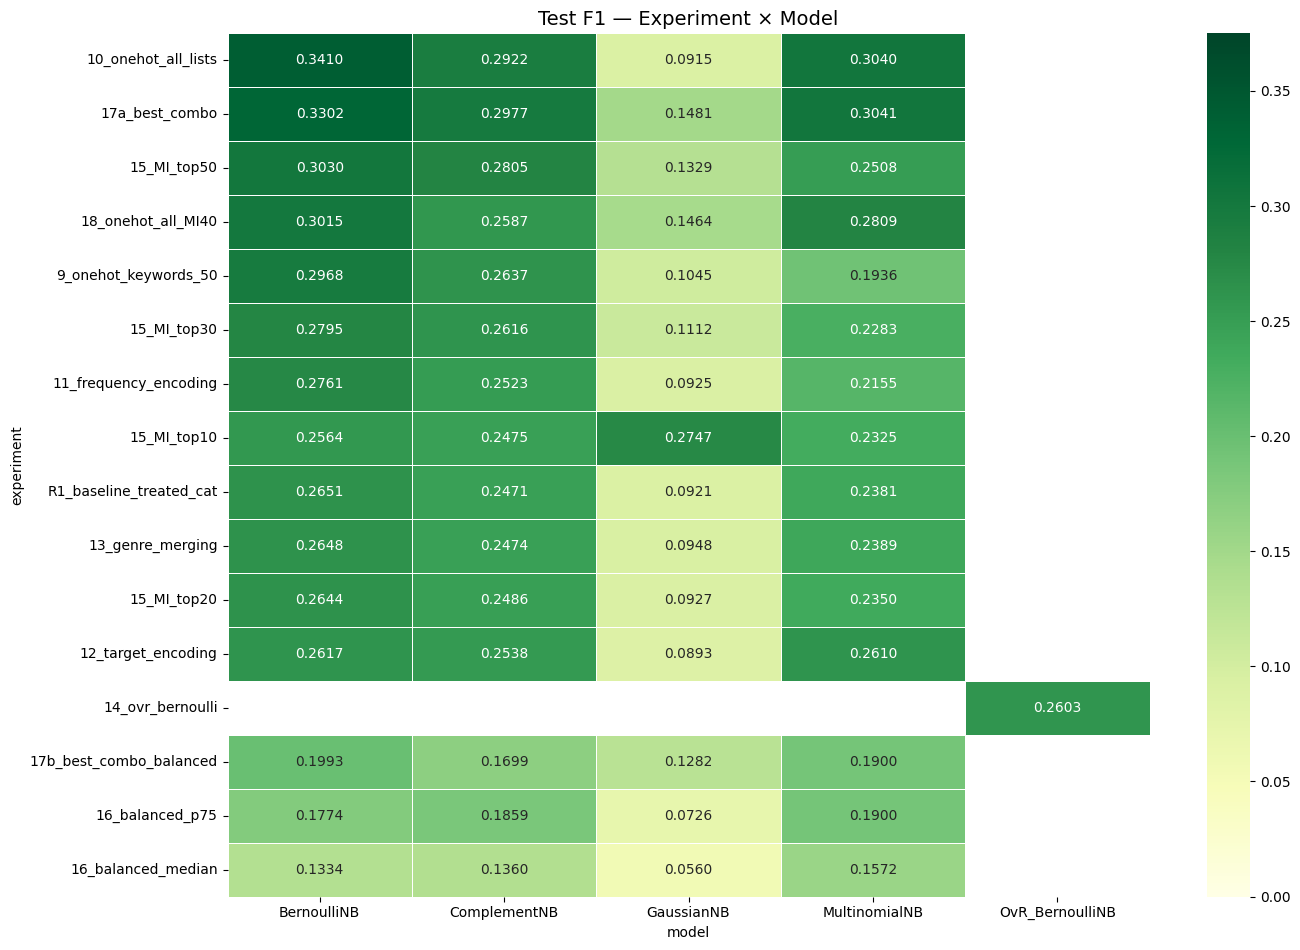

In [26]:
# Heatmap
pivot = comp.pivot_table(index='experiment', columns='model', values='test_f1')
pivot = pivot.reindex(best['experiment'])

fig, ax = plt.subplots(figsize=(14, max(6, len(pivot) * 0.6)))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn', ax=ax,
            linewidths=0.5, vmin=0, vmax=pivot.max().max() * 1.1)
ax.set_title('Test F1 — Experiment × Model', fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'round2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


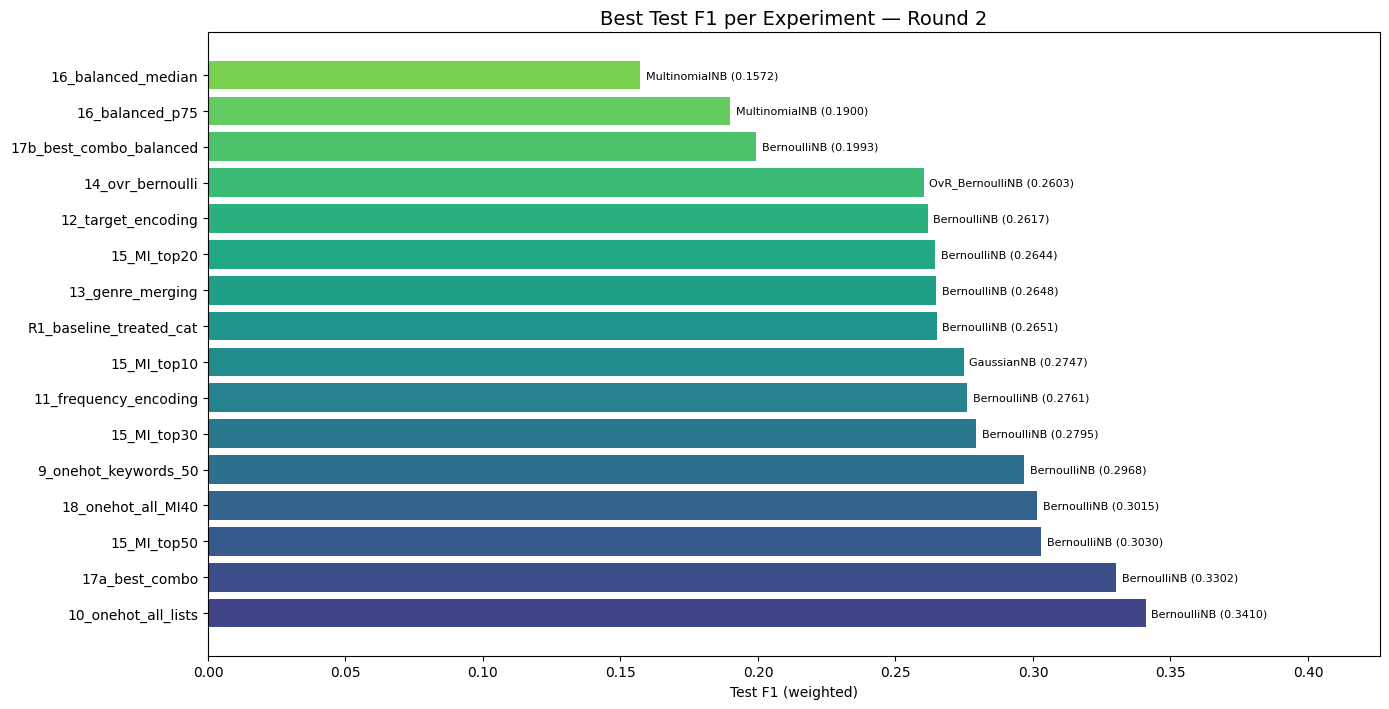

In [27]:
# Bar chart
fig, ax = plt.subplots(figsize=(14, max(5, len(best) * 0.45)))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(best)))
bars = ax.barh(best['experiment'], best['test_f1'], color=colors)
for bar, model in zip(bars, best['model']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{model} ({bar.get_width():.4f})', va='center', fontsize=8)
ax.set_xlabel('Test F1 (weighted)')
ax.set_title('Best Test F1 per Experiment — Round 2', fontsize=14)
ax.set_xlim(0, best['test_f1'].max() * 1.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'round2_bar.png', dpi=150, bbox_inches='tight')
plt.show()


In [28]:
# Summary
r1_f1 = ALL_RESULTS.get('R1_baseline_treated_cat', {})
r1_best = max((v['test_f1'] for v in r1_f1.values()), default=0) if r1_f1 else 0
overall_best_row = best.iloc[0]

print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Round 1 best (treated cat):  F1 = {r1_best:.4f}")
print(f"Round 2 best:                F1 = {overall_best_row['test_f1']:.4f}  "
      f"({overall_best_row['experiment']}, {overall_best_row['model']})")
improvement = overall_best_row['test_f1'] - r1_best
print(f"Improvement over R1:         {improvement:+.4f} ({improvement/max(r1_best,1e-9)*100:+.1f}%)")

print("\n--- What helped ---")
for _, row in best.iterrows():
    diff = row['test_f1'] - r1_best
    tag = "+" if diff > 0.005 else "=" if diff > -0.005 else "-"
    print(f"  [{tag}] {row['experiment']}: F1={row['test_f1']:.4f} (delta={diff:+.4f}), "
          f"{row['n_features']} features, {row['n_classes']} classes")


SUMMARY
Round 1 best (treated cat):  F1 = 0.2651
Round 2 best:                F1 = 0.3410  (10_onehot_all_lists, BernoulliNB)
Improvement over R1:         +0.0759 (+28.6%)

--- What helped ---
  [+] 10_onehot_all_lists: F1=0.3410 (delta=+0.0759), 197 features, 20 classes
  [+] 17a_best_combo: F1=0.3302 (delta=+0.0652), 83 features, 19 classes
  [+] 15_MI_top50: F1=0.3030 (delta=+0.0379), 50 features, 20 classes
  [+] 18_onehot_all_MI40: F1=0.3015 (delta=+0.0364), 40 features, 19 classes
  [+] 9_onehot_keywords_50: F1=0.2968 (delta=+0.0317), 67 features, 20 classes
  [+] 15_MI_top30: F1=0.2795 (delta=+0.0144), 30 features, 20 classes
  [+] 11_frequency_encoding: F1=0.2761 (delta=+0.0111), 26 features, 20 classes
  [+] 15_MI_top10: F1=0.2747 (delta=+0.0097), 10 features, 20 classes
  [=] R1_baseline_treated_cat: F1=0.2651 (delta=+0.0000), 26 features, 20 classes
  [=] 13_genre_merging: F1=0.2648 (delta=-0.0003), 26 features, 19 classes
  [=] 15_MI_top20: F1=0.2644 (delta=-0.0007), 20 fea